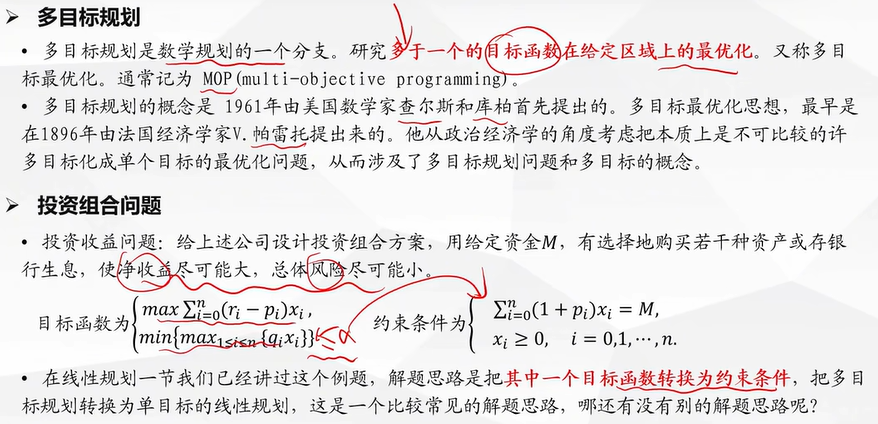

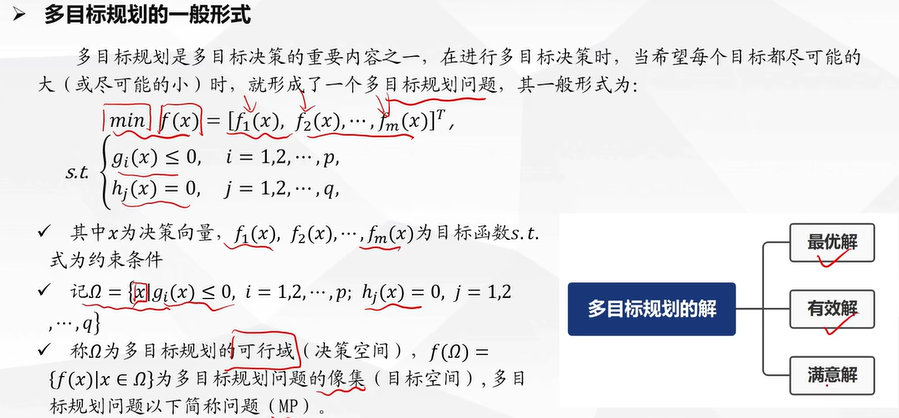

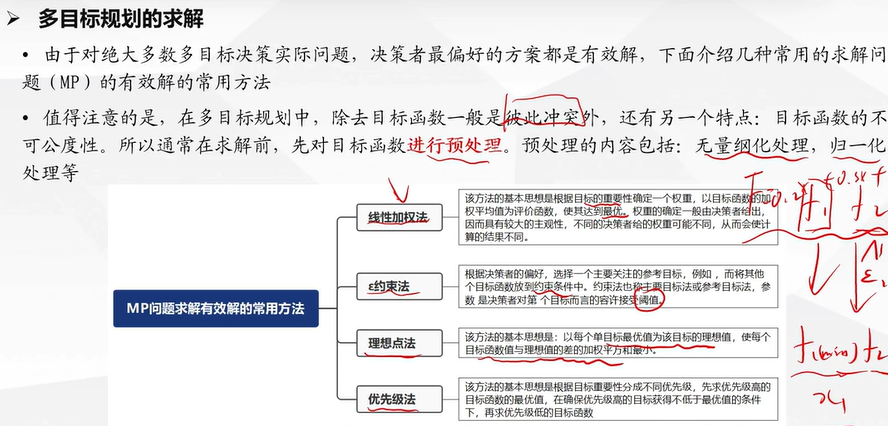

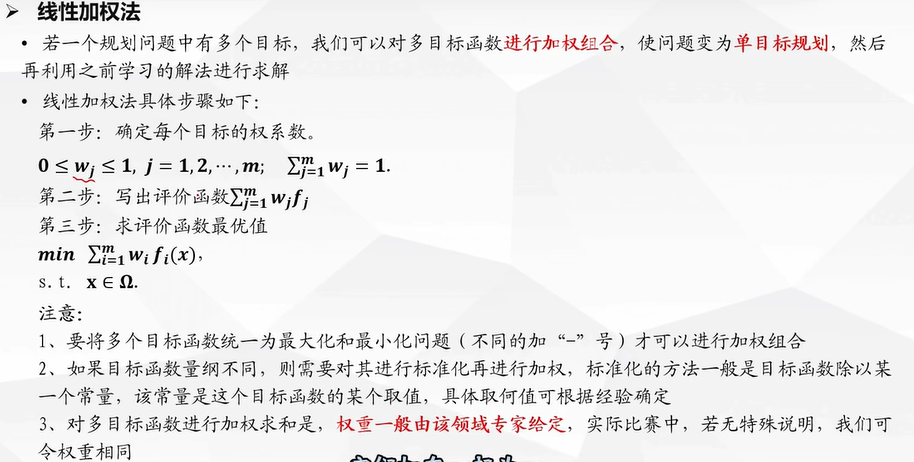

### 典型例题：
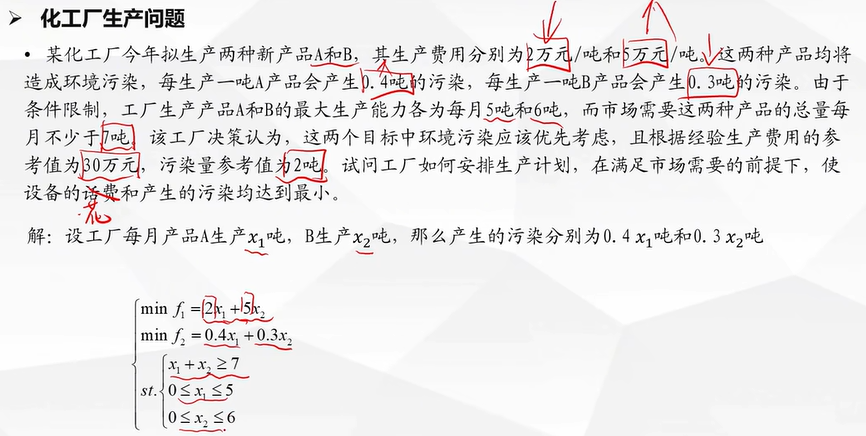

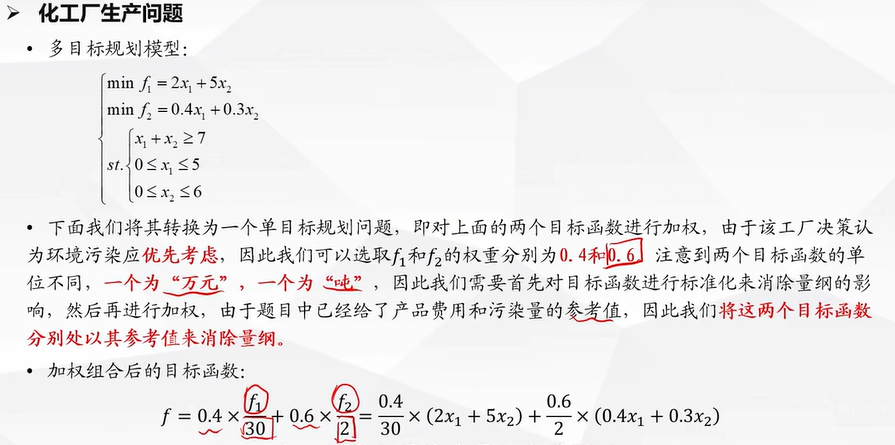

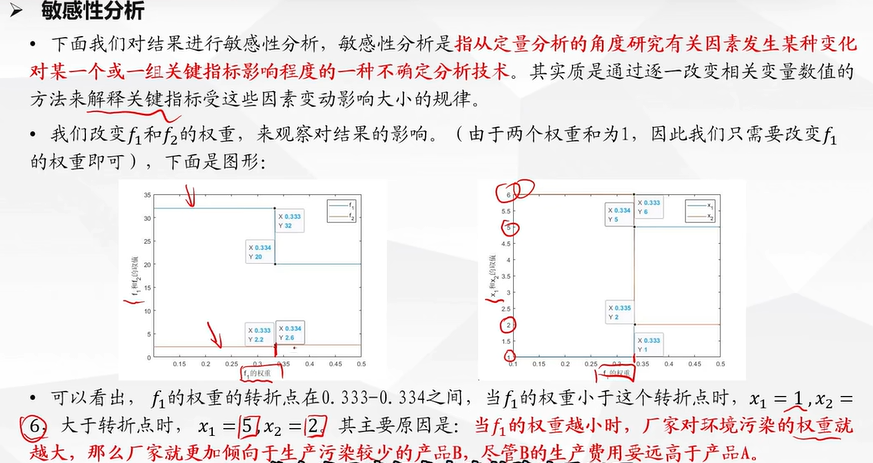


权重组合：w1=0.4, w2=0.6
最优解：x1=5.00, x2=2.00
目标函数值：f1=20.00, f2=2.60, 综合指标=1.05

权重组合：w1=0.5, w2=0.5
最优解：x1=5.00, x2=2.00
目标函数值：f1=20.00, f2=2.60, 综合指标=0.98

权重组合：w1=0.3, w2=0.7
最优解：x1=1.00, x2=6.00
目标函数值：f1=32.00, f2=2.20, 综合指标=1.09


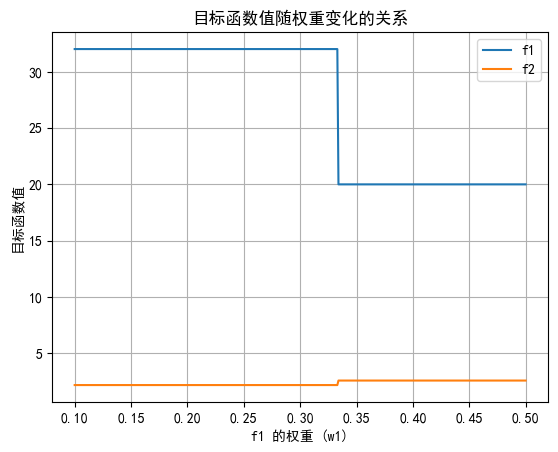

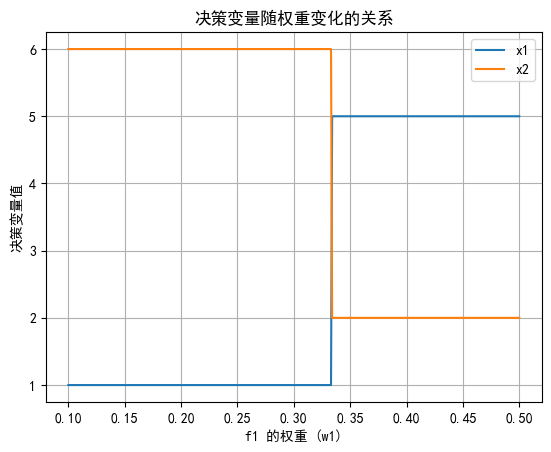

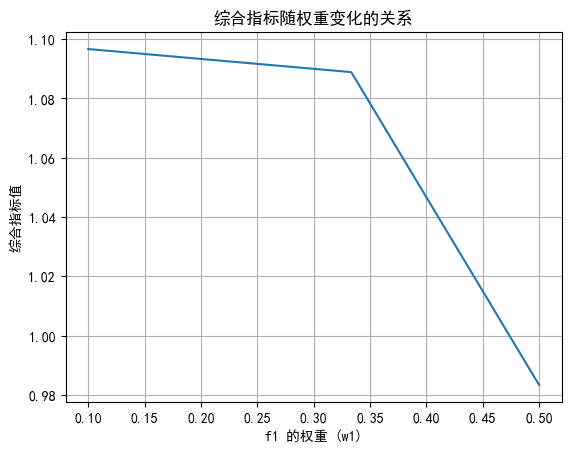

In [4]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 多目标规划问题
weights = [
    (0.4, 0.6),  # w1 = 0.4, w2 = 0.6
    (0.5, 0.5),  # w1 = 0.5, w2 = 0.5
    (0.3, 0.7)   # w1 = 0.3, w2 = 0.7
]

# 定义约束条件
A = [[-1, -1]]  # 不等式约束 A @ x <= b
b = [-7]        # 右端项
lb = [0, 0]     # 下界
ub = [5, 6]     # 上界
bounds = [(lb[0], ub[0]), (lb[1], ub[1])]

# 遍历不同权重组合，求解线性规划
for w1, w2 in weights:
    # 构造目标函数系数
    c = [w1 / 30 * 2 + w2 / 2 * 0.4, w1 / 30 * 5 + w2 / 2 * 0.3]

    # 求解线性规划
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')
    
    x = result.x  # 变量 x 的最优解
    fval = result.fun  # 目标函数的最优值

    # 计算目标函数值
    f1 = 2 * x[0] + 5 * x[1]
    f2 = 0.4 * x[0] + 0.3 * x[1]

    # 打印结果
    print(f"\n权重组合：w1={w1}, w2={w2}")
    print(f"最优解：x1={x[0]:.2f}, x2={x[1]:.2f}")
    print(f"目标函数值：f1={f1:.2f}, f2={f2:.2f}, 综合指标={fval:.2f}")


# ===========敏感度分析===========
# 权重范围
W1 = np.arange(0.1, 0.501, 0.001)  # w1 从 0.1 到 0.5，步长 0.001
W2 = 1 - W1                          # w2 = 1 - w1
n = len(W1)

# 初始化结果存储数组
F1 = np.zeros(n)  # 存储 f1 的值
F2 = np.zeros(n)  # 存储 f2 的值
X1 = np.zeros(n)  # 存储 x1 的最优解
X2 = np.zeros(n)  # 存储 x2 的最优解
FVAL = np.zeros(n)  # 存储综合目标函数值

# 遍历不同权重，执行敏感性分析
for i in range(n):
    w1 = W1[i]
    w2 = W2[i]
    c = [w1 / 30 * 2 + w2 / 2 * 0.4, w1 / 30 * 5 + w2 / 2 * 0.3]

    # 求解线性规划
    result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')
    
    x = result.x
    F1[i] = 2 * x[0] + 5 * x[1]           # f1 的值
    F2[i] = 0.4 * x[0] + 0.3 * x[1]       # f2 的值
    X1[i] = x[0]                          # x1 的最优解
    X2[i] = x[1]                          # x2 的最优解
    FVAL[i] = result.fun                  # 综合目标函数值


# 绘图
# 设置字体为支持中文的字体，例如 SimHei（黑体）
rcParams['font.sans-serif'] = ['SimHei']  # 选择黑体
rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 图1：权重与目标函数值的关系
plt.figure()
plt.plot(W1, F1, label='f1')
plt.plot(W1, F2, label='f2')
plt.xlabel("f1 的权重 (w1)")
plt.ylabel("目标函数值")
plt.legend()
plt.title("目标函数值随权重变化的关系")
plt.grid()

# 图2：权重与决策变量的关系
plt.figure()
plt.plot(W1, X1, label='x1')
plt.plot(W1, X2, label='x2')
plt.xlabel("f1 的权重 (w1)")
plt.ylabel("决策变量值")
plt.legend()
plt.title("决策变量随权重变化的关系")
plt.grid()

# 图3：权重与综合指标的关系
plt.figure()
plt.plot(W1, FVAL)
plt.xlabel("f1 的权重 (w1)")
plt.ylabel("综合指标值")
plt.title("综合指标随权重变化的关系")
plt.grid()

# 显示所有图
plt.show()